In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# For example, here's several helpful packages to load
# https://www.kaggle.com/code/hobeomlee/fraud-detection-modeling-guidebook-a-to-z

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
import os
#os.listdir()

for dirname, _, filenames in os.walk('/Users/Admin/Desktop/Predictive-Analysis/fraud_oracle/'):
   for filename in filenames:
        print(os.path.join(dirname, filename))


/Users/Admin/Desktop/Predictive-Analysis/fraud_oracle/fraud_oracle.csv


In [3]:
# Null Values
import missingno as msno

# Visualization - Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

# Encoding
from sklearn.preprocessing import LabelEncoder

# Handling Outliers
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


# SMOTE Oversampling
from imblearn.over_sampling import SMOTE

# VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

# RFECV
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Machine Learning - Preparation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Machine Learning - Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Machine Learning - Optuna
import optuna
from optuna.samplers import TPESampler

# Machine Learning - Feature Importance
from sklearn.inspection import permutation_importance


# 01. Descriptive Analysis

In [9]:

raw_data = pd.read_csv('/Users/Admin/Desktop/Predictive-Analysis/fraud_oracle/fraud_oracle.csv')
raw_data.shape

(15420, 33)

In [5]:
# Set-up
pd.set_option('display.max_columns', None)

## 01) Definition of Features

In [11]:

raw_data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 02) Missing Values

<Axes: >

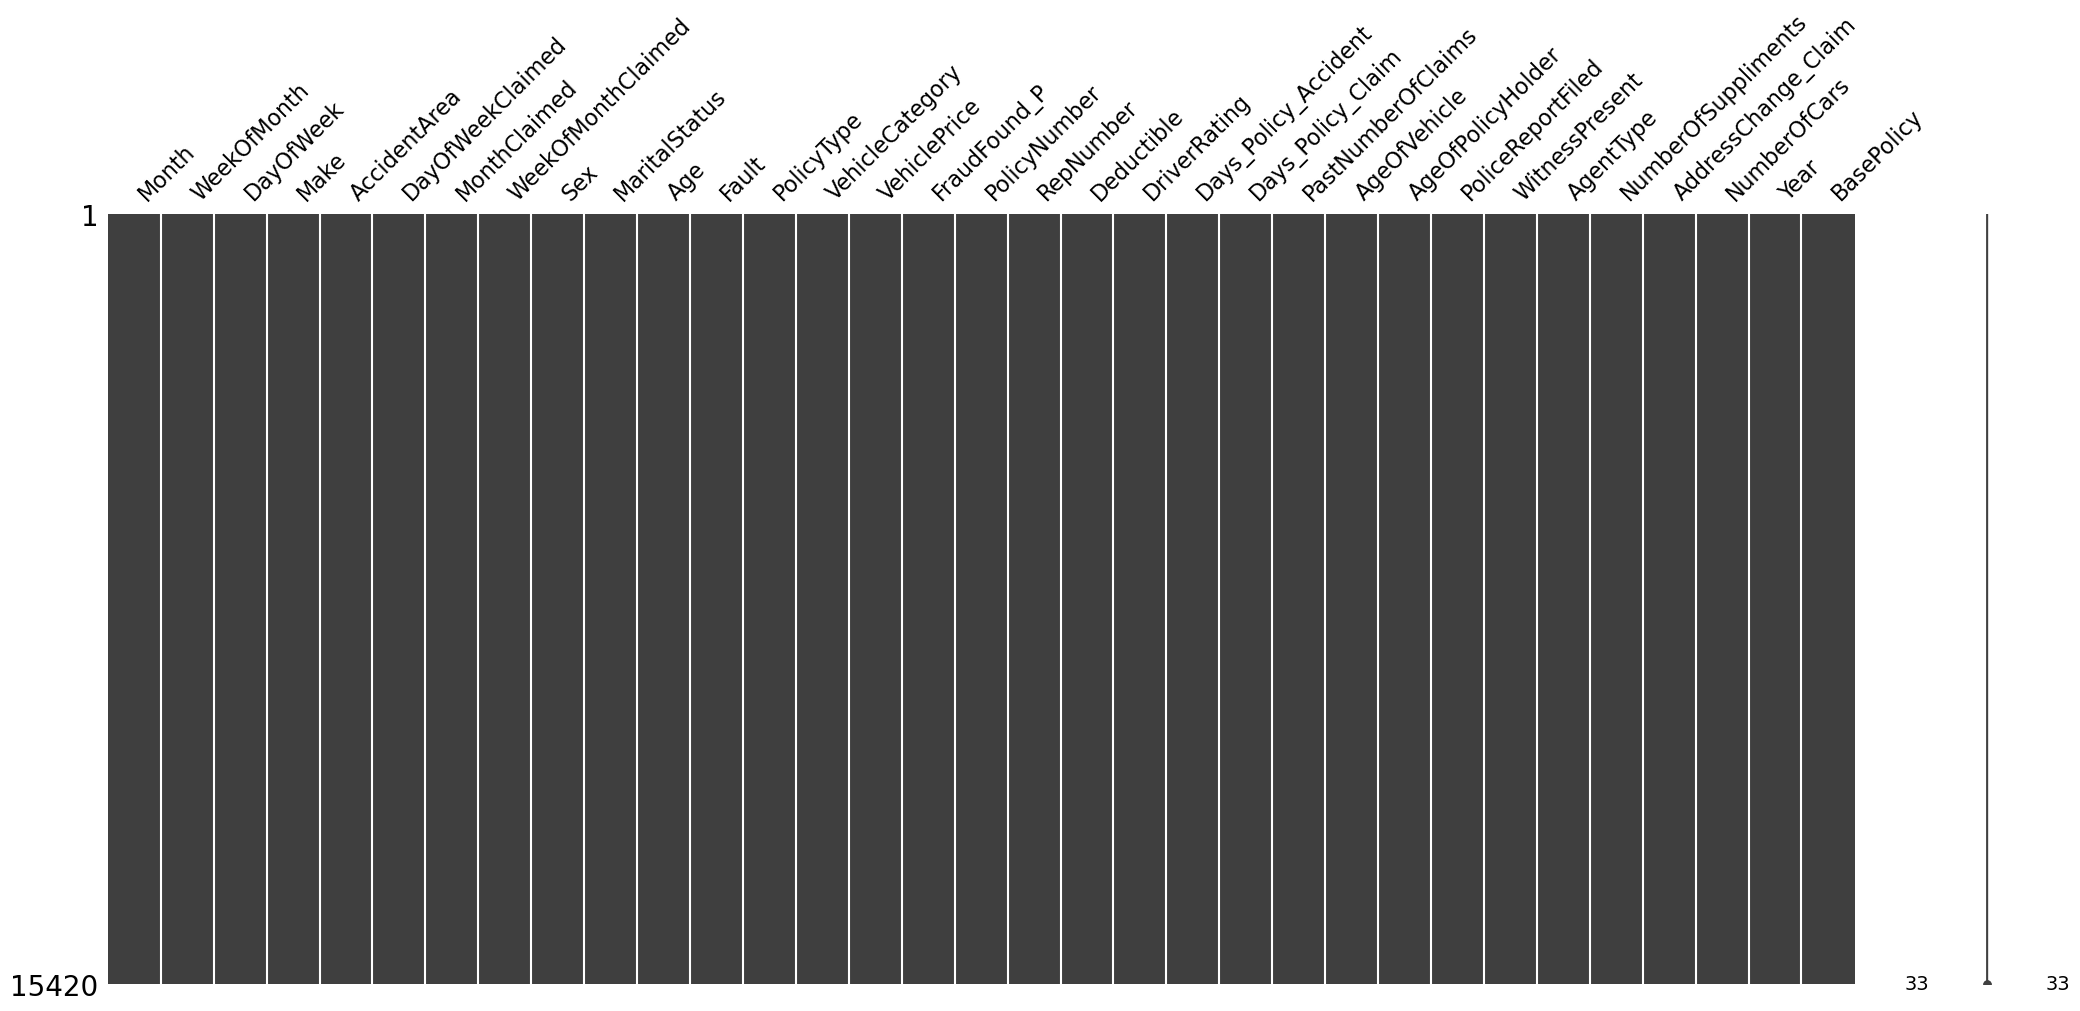

In [13]:

msno.matrix(raw_data)

In [15]:
raw_data.isna().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

**Point 01**: No missing data

## 03) Characteristic of Dataset

### Function 01: Summarize the characteristic of dataset

In [17]:


def summarize(DataFrame):
    
    summary = pd.DataFrame()
    
    # Data Type
    summary['Data Type'] = DataFrame.dtypes
    # N Unique
    summary['N Unique'] = DataFrame.nunique()
    # Unique
    summary['Unique'] = DataFrame.apply(lambda x: x.unique().tolist())
    # Max
    summary['Max'] = DataFrame.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else '-')
    # Min
    summary['Min'] = DataFrame.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Central Tendency: Mean, Median, Mode 
    summary['Mean'] = DataFrame.apply(lambda x: round(x.mean(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Median'] = DataFrame.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Mode'] = DataFrame.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else '-')
    
    # Measures of Dispersion: Range, Variance, Standard Deviation
    summary['Range'] = DataFrame.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Variance'] = DataFrame.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Standard Deviation'] = DataFrame.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Shape: Skewness, Kurtosis
    summary['Skewness'] = DataFrame.apply(lambda x: round(x.skew(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Kurtosis'] = DataFrame.apply(lambda x: round(x.kurt(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    
    return summary

In [21]:
summary = summarize(raw_data)
summary

,Data Type,N Unique,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",5,1,2.79,3.0,3,4,1.657876,1.287585,0.12,-1.1
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",-,-,-,-,Monday,-,-,-,-,-
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",-,-,-,-,Pontiac,-,-,-,-,-
AccidentArea,object,2,"[Urban, Rural]",-,-,-,-,Urban,-,-,-,-,-
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",-,-,-,-,Monday,-,-,-,-,-
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",5,1,2.69,3.0,2,4,1.585371,1.259115,0.16,-1.09
Sex,object,2,"[Female, Male]",-,-,-,-,Male,-,-,-,-,-
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",-,-,-,-,Married,-,-,-,-,-


**Point 02**: "PolicyNumber" is merely an identification number. Let's drop it.

**Point 03**: The features "Sex", "PoliceReportFiled", and "WitnessPresent" are actually Boolen Types. Should be converted to 0 or 1.

**Point 04**: The features "AccidentalArea", "Fault", and "AgentType" each have only two unique values. Can also be converted to 0 or 1.

**Point 05**: The minimum value of "Age" is 0. It totally doesn't make sense. (Let me look into it later.)

**Point 06**: The features "FraudFound_P" and "Deductible" are highly skewed; Typically, a feature is considered skewed if its skewness falls outside the range of -0.5~0.5.

**Point 07**: The features "WeekOfMonth", "WeekOfMonthClaimed", "FraudFound_P", "Deductible", and "DriverRating" exhibit high kurtosis; Typically a feature is considered to have high kurtosis if its value falls outside the range of -1 ~ 1.

**Point 08**: Strictly speaking, among all the features, only Age is a numeric variable. The rest can be interpreted as categorical variables.

# 02. Exploratory Data Analysis (EDA)

In [19]:

df_viz = raw_data.copy()
df_viz.shape

(15420, 33)

## 01) Target Variable Balance - Fraud_Found_P

In [21]:

fraud_counts = df_viz['FraudFound_P'].value_counts().reset_index()
fraud_counts.columns = ['FraudFound_P', 'Count']
fraud_counts

,FraudFound_P,Count
0,0,14497
1,1,923


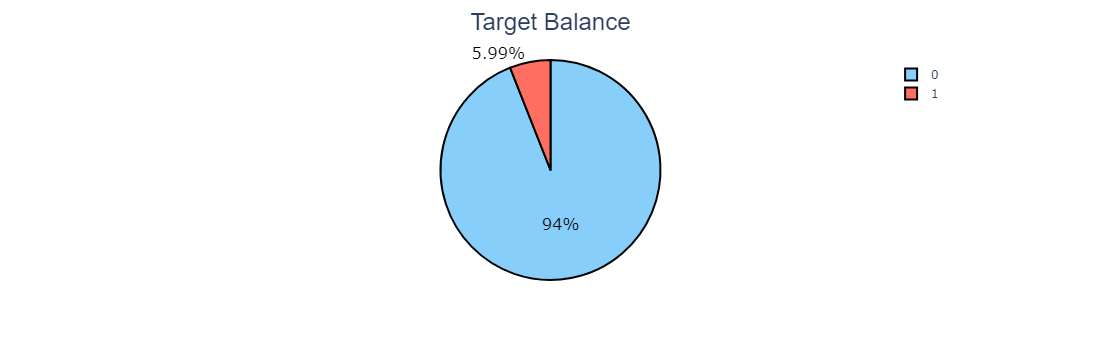

In [25]:
# Pie Chart
fig = px.pie(fraud_counts, names='FraudFound_P', values='Count', color='FraudFound_P',
            color_discrete_map={0: '#87CEFA', 1:'FF6F61'})

fig.update_traces(
    textinfo='percent',
    textfont={'size': 16, 'color': 'Black'},
    marker=dict(line=dict(color='black', width=2)))

fig.update_layout(
    title={
        'text': 'Target Balance',
        'x':0.5,
        'font': {'family': "Arial, sans-serif", 'size': 24}
    })

fig.show()

**Point 09**: The Target Variable "Fraud_Found_P" is highly imbalanced.
    
**Issues** Caused by Imbalanced Target Variable

**Model Bias**: The model may become biased towards the majority class, leading to poor performance on the minority class.

**Misleading Metrics**: Metrics like accuracy can be misleading, as high accuracy can be achieved by simply predicting the majority class.
    
**Poor Generalization**: The model may not generalize well to real-world scenarios where the minority class is important.

## 02) Fraud Detection by Sex

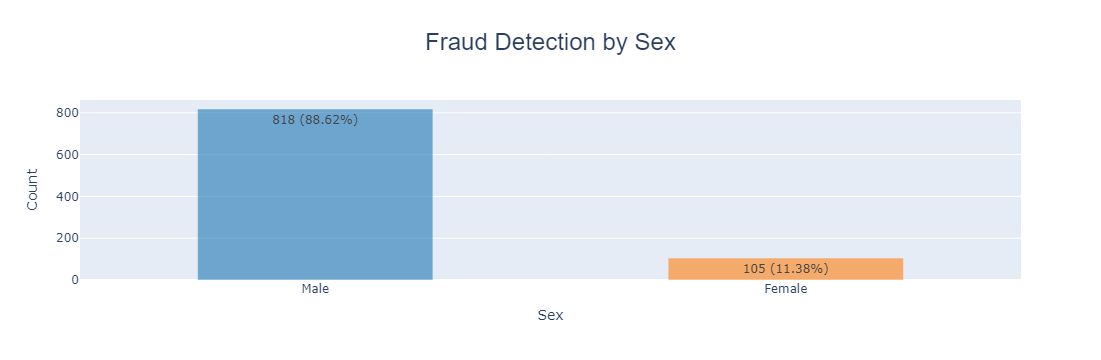

In [27]:
df_fraud = df_viz[df_viz['FraudFound_P'] == 1]

fraud_counts_sex = df_fraud['Sex'].value_counts()
fraud_percentages_sex = (fraud_counts_sex / fraud_counts_sex.sum()) * 100
fraud_percentages_sex

# Bar Chart
fig = go.Figure()

fig.add_trace(go.Bar(x=fraud_counts_sex.index, y=fraud_counts_sex.values,
                    text=[f'{count} ({percentage:.2f}%)' for count, percentage in zip(fraud_counts_sex.values, fraud_percentages_sex)],
                    textposition='auto', marker_color=['rgba(31, 119, 180, 0.6)', 'rgba(255, 127, 14, 0.6)'], width=0.5))

fig.update_layout(
    title={
        'text': 'Fraud Detection by Sex',
        'x':0.5,
        'font': {'family': "Arial, sans-serif", 'size': 24}
    })

fig.update_layout(
    xaxis=dict(title='Sex'),
    yaxis=dict(title='Count'),
    showlegend=False)

fig.show()


**Deductible**: The amount that the policy holder must pay out of pocket before the insurance company pays the remaining costs.

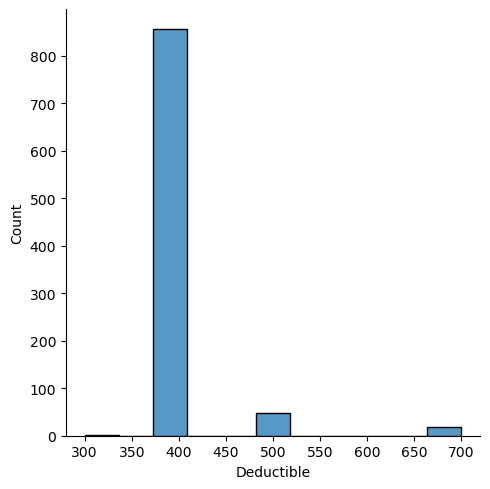

In [45]:

sns.displot(df_fraud, x="Deductible")

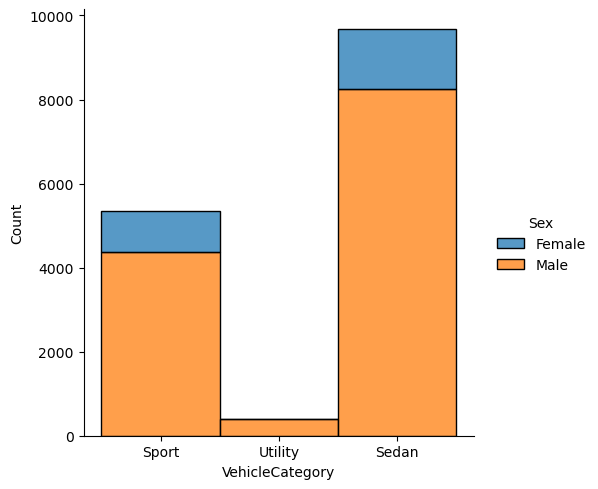

In [59]:
sns.displot(raw_data, x="VehicleCategory",hue="Sex", multiple="stack")

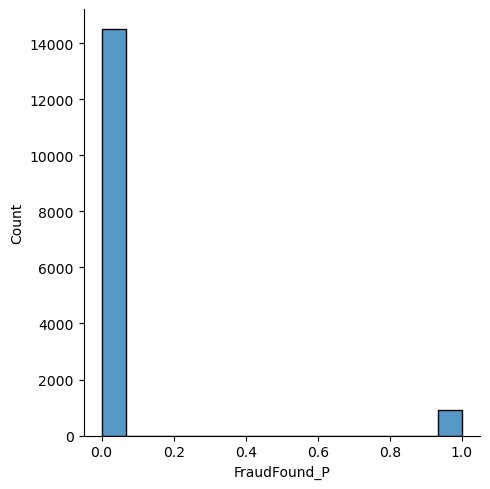

In [51]:
sns.displot(raw_data, x="FraudFound_P")

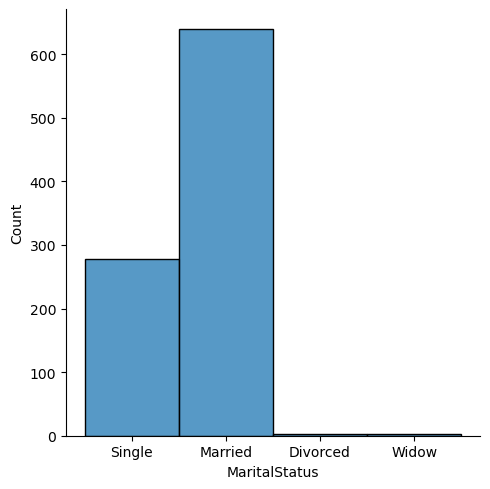

In [55]:
sns.displot(df_fraud, x="MaritalStatus")

## 03) Fraud Detection by Age & Age of Policy Holder

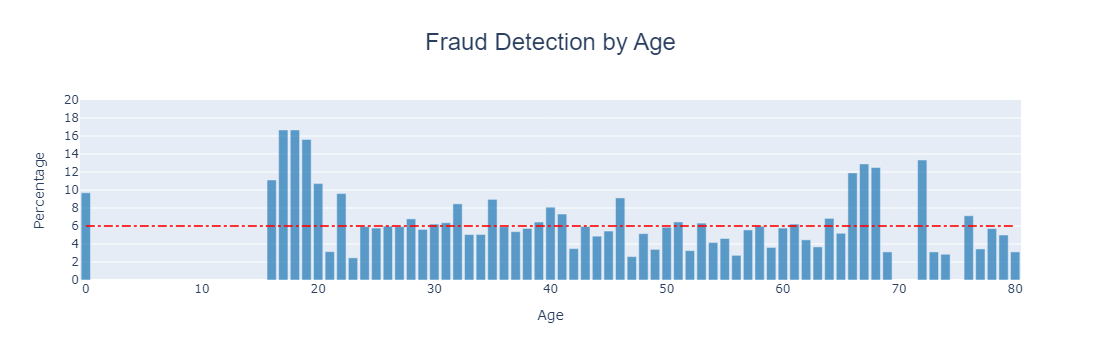

In [29]:
df_fraud = df_viz[df_viz['FraudFound_P'] == 1]
df_non_fraud = df_viz[df_viz['FraudFound_P'] == 0]

df_counts_age = df_viz['Age'].value_counts().sort_index()
df_counts_fraud = df_fraud['Age'].value_counts().sort_index()

df_percentages_fraud = round((df_counts_fraud / df_counts_age) * 100, 2)

# Bar Chart
fig = go.Figure()

fig.add_trace(go.Bar(x=df_percentages_fraud.index, y=df_percentages_fraud.values,
    marker_color='rgba(31, 119, 180, 0.7)'))

fig.update_layout(
    title={
        'text': 'Fraud Detection by Age',
        'x':0.5,
        'font': {'family': "Arial, sans-serif", 'size': 24}
    })

fig.update_layout(
    xaxis=dict(title='Age'), yaxis=dict(title='Percentage', range=[0, 20], dtick=2), legend=dict(title='Outcome'))

fig.add_shape(
    type="line",
    x0=min(df_percentages_fraud.index),
    y0=6,
    x1=max(df_percentages_fraud.index),
    y1=6,
    line=dict(
        color="rgba(255, 0, 0, 0.8)",
        width=2,
        dash="dashdot",
    ),
)

fig.show()

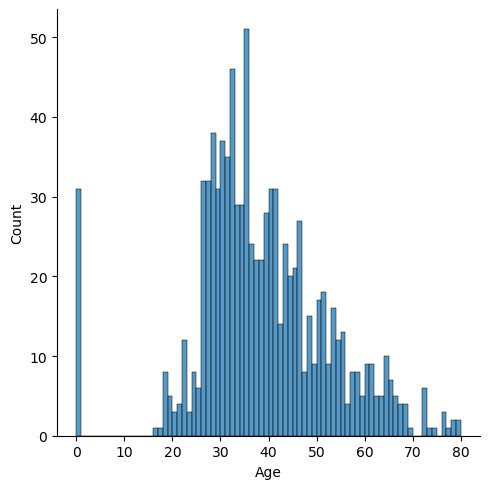

In [71]:
sns.displot(df_fraud, x="Age", bins=80)

**Point 11-1**: Fraud is most frequently detected among teenagers and retired seniors. Teenagers have weak financial power as they have not yet started their economic activities, and retired seniors experience weakened financial power post-retirement. Considering these points, there seems to be a correlation between financial power and fraud.



## 04) Fraud Detection by Make

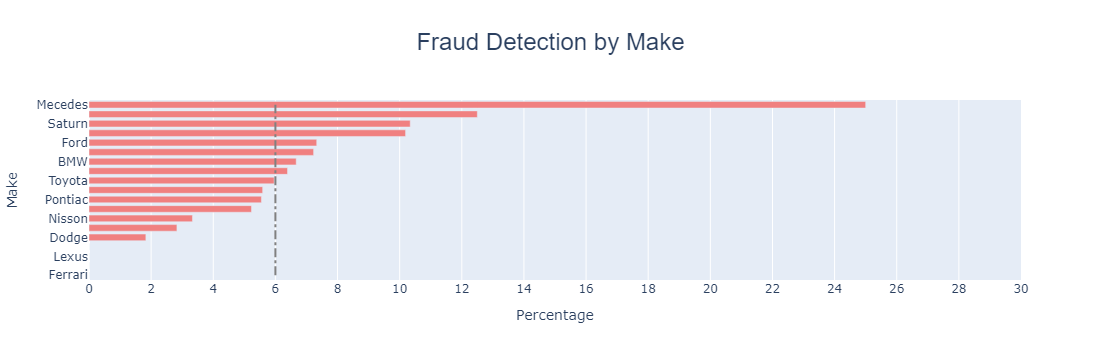

In [31]:
df_counts_make = df_viz['Make'].value_counts().sort_index()
df_counts_fraud2 = df_fraud['Make'].value_counts().sort_index()
df_percentages_fraud2 = pd.DataFrame(round((df_counts_fraud2 / df_counts_make) * 100, 2)).fillna(0).reset_index()

df_percentages_fraud2.columns = ['Make', 'Fraud %']
df_percentages_fraud2 = df_percentages_fraud2.sort_values(by=['Fraud %', 'Make'])

# Bar Chart
fig = go.Figure()

fig.add_trace(go.Bar(x=df_percentages_fraud2['Fraud %'], y=df_percentages_fraud2['Make'], orientation='h',
    marker_color='lightcoral'))

fig.update_layout(
    title={
        'text': 'Fraud Detection by Make',
        'x':0.5,
        'font': {'family': "Arial, sans-serif", 'size': 24}
    })

fig.update_layout(
    xaxis=dict(title='Percentage', range=[0, 30], dtick=2), yaxis=dict(title='Make'), legend=dict(title='Outcome'), bargap=0.3)

fig.add_shape(
    type="line",
    x0=6,
    y0=0,
    x1=6,
    y1=len(df_percentages_fraud2['Make']) - 1,
    line=dict(
        color="rgba(128, 128, 128, 1)",
        width=2,
        dash="dashdot", 
    ),
)

fig.show()

## 05) Fraud Detection by Vehicle Price

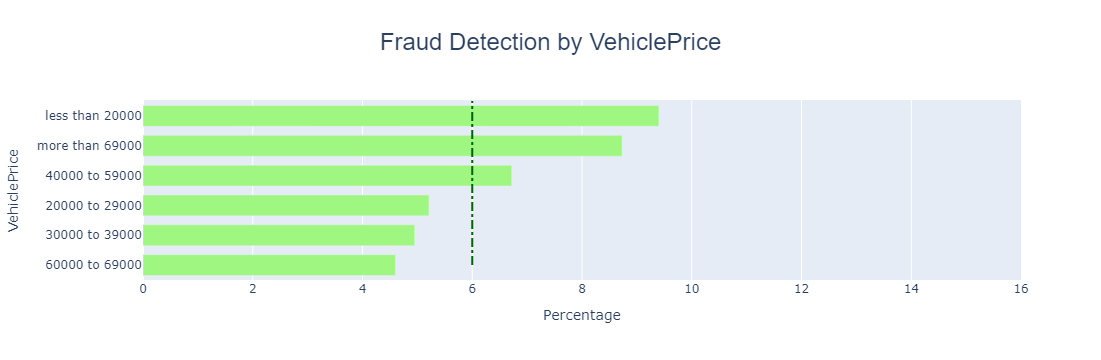

In [76]:
df_counts_vp = df_viz['VehiclePrice'].value_counts().sort_index()
df_counts_fraud3 = df_fraud['VehiclePrice'].value_counts().sort_index()
df_percentages_fraud3 = pd.DataFrame(round((df_counts_fraud3 / df_counts_vp) * 100, 2)).fillna(0).reset_index()

df_percentages_fraud3.columns = ['VehiclePrice', 'Fraud %']
df_percentages_fraud3 = df_percentages_fraud3.sort_values(by=['Fraud %'])

# Bar Chart
fig = go.Figure()

fig.add_trace(go.Bar(x=df_percentages_fraud3['Fraud %'], y=df_percentages_fraud3['VehiclePrice'], orientation='h',
    marker_color='#9FF781'))

fig.update_layout(
    title={
        'text': 'Fraud Detection by VehiclePrice',
        'x':0.5,
        'font': {'family': "Arial, sans-serif", 'size': 24}
    })

fig.update_layout(
    xaxis=dict(title='Percentage', range=[0, 16], dtick=2), yaxis=dict(title='VehiclePrice'), legend=dict(title='Outcome'), bargap=0.3)

fig.add_shape(
    type="line",
    x0=6,
    y0=0,
    x1=6,
    y1=5.5,
    line=dict(
        color="rgba(0, 100, 0, 1)",
        width=2,
        dash="dashdot", 
    ),
)

fig.show()

# 03. Data Preprocessing

In [33]:
df_clean_v1 = raw_data.copy()
df_clean_v1.shape

(15420, 33)

## 01) Data Transformation - Encoding Categorical Variables (Binary Variable)

In [84]:
binary_columns = [col for col in df_clean_v1.columns if df_clean_v1[col].nunique() == 2 and col != 'FraudFound_P']

In [86]:
print('The number of Binary Columns: ', len(binary_columns))
print('Binary Columns: ', binary_columns)

The number of Binary Columns:  6
Binary Columns:  ['AccidentArea', 'Sex', 'Fault', 'PoliceReportFiled', 'WitnessPresent', 'AgentType']


In [88]:
le = LabelEncoder()

for col  in binary_columns:
    df_clean_v1[col] = le.fit_transform(df_clean_v1[col])
    print('Label Mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping:  {'Rural': 0, 'Urban': 1}
Label Mapping:  {'Female': 0, 'Male': 1}
Label Mapping:  {'Policy Holder': 0, 'Third Party': 1}
Label Mapping:  {'No': 0, 'Yes': 1}
Label Mapping:  {'No': 0, 'Yes': 1}
Label Mapping:  {'External': 0, 'Internal': 1}


## 02) Data Transformation - Encoding Categorical Variables (Ordinal Categorical Variables & Nominal Categorical Variables) 

An **Ordinal Categorical Variable** is a categorical variable where the categories have a logical order or ranking (e.g., low, medium, high)

A **Nominal Categorical Variable** is a categorical variable where the categories do not have a logical order or ranking (e.g., red, blue, green).

In [90]:
for col in ['VehiclePrice', 'DriverRating', 'AgeOfVehicle', 'BasePolicy']:
    print(f"The unique values in {col}: {df_clean_v1[col].unique()}")

The unique values in VehiclePrice: ['more than 69000' '20000 to 29000' '30000 to 39000' 'less than 20000'
 '40000 to 59000' '60000 to 69000']
The unique values in DriverRating: [1 4 3 2]
The unique values in AgeOfVehicle: ['3 years' '6 years' '7 years' 'more than 7' '5 years' 'new' '4 years'
 '2 years']
The unique values in BasePolicy: ['Liability' 'Collision' 'All Perils']


"VehiclePrice" is converted into a binary variable rather than an ordinal one. This decision was based on the fact that the categories "more than 69000" and "less than 20000" have the highest fraud rates, showing that the feature does not follow an ordinal pattern. 

"AgeOfVehicle" is transformed into a nominal categorical variable for the same reason as "VehiclePrice." However, this feature can be re-classified into three categories. 

Only, "BasePolicy" keeps its natural characteristic as a ordinal categorical variable

In [92]:
vehicleprice_label = {'more than 69000': 1, '20000 to 29000': 0,  '30000 to 39000': 0, 'less than 20000': 1, '40000 to 59000': 1, '60000 to 69000': 0}
ageofvehicle_label = {'new': 2, '2 years': 0, '3 years': 2, '4 years': 2, '5 years': 1, '6 years': 1, '7 years': 0, 'more than 7': 0}
basepolicy_label = {'Liability': 0, 'Collision': 1, 'All Perils': 2}

In [94]:
df_clean_v1['VehiclePrice'] = df_clean_v1['VehiclePrice'].map(vehicleprice_label)
df_clean_v1['AgeOfVehicle'] = df_clean_v1['AgeOfVehicle'].map(ageofvehicle_label)
df_clean_v1['BasePolicy'] = df_clean_v1['BasePolicy'].map(basepolicy_label)

In [96]:
df_clean_v2 = df_clean_v1.copy()
df_clean_v2.shape

(15420, 33)

## 03) Data Reduction - Feature Selection 01 (Drop Useless Columns)

In [98]:
useless_columns = ['Month', 'WeekOfMonth', 'DayOfWeek', 'DayOfWeekClaimed', 'WeekOfMonthClaimed', 'PolicyNumber']
df_clean_v3 = df_clean_v2.drop(columns=useless_columns, axis=1)
df_clean_v3.shape

(15420, 27)

## 04) Data Transformation - One-hot Endoing (Other categorical variables)

In [100]:
dtype_change_string = ['RepNumber', 'Deductible', 'Year']

for col in dtype_change_string:
    df_clean_v3[col] = df_clean_v3[col].astype(str)

In [41]:
onehot_encoding_columns = ['Make', 'MonthClaimed', 'MaritalStatus', 'PolicyType', 'VehicleCategory', 'RepNumber', 'Deductible', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfPolicyHolder', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year']
print("The number of one-hot encoding target features: ", len(onehot_encoding_columns))

The number of one-hot encoding target features:  15


In [104]:
df_clean_v4 = pd.get_dummies(df_clean_v3, columns=onehot_encoding_columns)
df_clean_v4.shape

(15420, 119)

## 05) Data Reduction - Feature Selection 02 (Drop Constant Features)

In [106]:
onehot_encoded_columns = [col for col in df_clean_v4.columns if '_' in col]
onehot_encoded_columns.remove("FraudFound_P")
print("The Number of One-hot Encoded Columns: ", len(onehot_encoded_columns))

The Number of One-hot Encoded Columns:  107


In [108]:
constant_features = []
for col in onehot_encoded_columns:
    if df_clean_v4[col].sum() <= 5:
        constant_features.append(col)
print("The Number of Constant Features: ", len(constant_features))

The Number of Constant Features:  9


In [110]:
df_clean_v4.drop(columns=constant_features, axis=1, inplace=True)
df_clean_v4.shape

(15420, 110)

## 06) Data Cleaning - Correcting Inaccurate Data & Handling Outliers (Age)

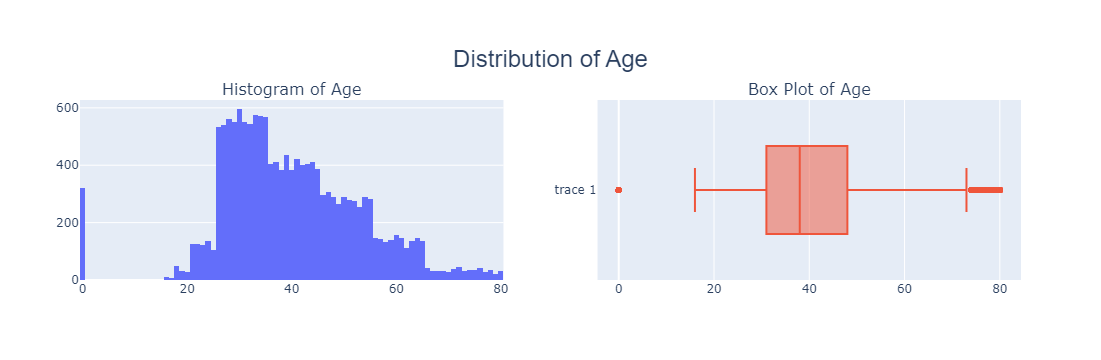

In [33]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram of Age", "Box Plot of Age"))

# Histogram
fig.add_trace(go.Histogram(x=df_viz['Age'], nbinsx=100), row=1, col=1)
# Box Plot
fig.add_trace(go.Box(x=df_viz['Age']), row=1, col=2)

fig.update_layout(
    title={
        'text': 'Distribution of Age', 'x':0.5,
        'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': 'Arial, sans-serif', 'size': 24}
    }, showlegend=False
)

fig.show()

In [114]:
# Function02: Outlier Replacement using LightGBM
def lightgbm_imputation(dataframe, feature):
    df_copy = dataframe.copy()
    train_data = df_copy[df_copy[feature].notnull()]
    test_data = df_copy[df_copy[feature].isnull()]
    
    X_train = train_data.drop(columns=[feature], axis=1)
    y_train = train_data[feature]
    X_test = test_data.drop(columns=[feature], axis=1)
    
    train_dataset = lgb.Dataset(X_train, label=y_train)
    
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbose': -1
    }
    
    model = lgb.train(params, train_dataset, num_boost_round=100)
    
    predictions = model.predict(X_test)
    
    df_copy.loc[df_copy[feature].isnull(), feature] = predictions
     
    return df_copy
    

In [116]:
# Change 0s and outliers into NullValues
df_clean_v4['Age'] = df_clean_v4['Age'].apply(lambda x: np.nan if x == 0 or x > 74 else x)

In [118]:
# Apply LightGBM Imputation
df_imputed = lightgbm_imputation(df_clean_v4, 'Age')

In [120]:
# Round up floats
df_imputed['Age'] = df_imputed["Age"].apply(lambda x: round(x))


In [122]:
# Function03: Categorize Age
def categorize_age(age):
    if age <= 20:
        return 0
    elif age <= 40:
        return 1
    elif age <= 65:
        return 2
    else:
        return 3

In [124]:
df_imputed['Age'] = df_imputed['Age'].apply(categorize_age)

In [126]:
df_clean_v5 = df_imputed.copy()
df_clean_v5.shape

(15420, 110)

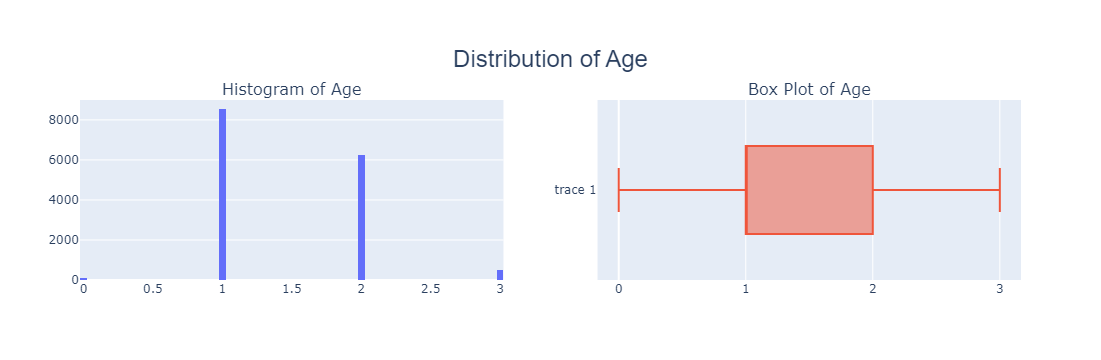

In [164]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram of Age", "Box Plot of Age"))

# Histogram
fig.add_trace(go.Histogram(x=df_clean_v5['Age'], nbinsx=100), row=1, col=1)
# Box Plot
fig.add_trace(go.Box(x=df_clean_v5['Age']), row=1, col=2)

fig.update_layout(
    title={
        'text': 'Distribution of Age', 'x':0.5,
        'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': 'Arial, sans-serif', 'size': 24}
    }, showlegend=False
)

fig.show()

# 04. SMOTE Oversampling

In [128]:
# Train - Test Split
X = df_clean_v5.drop(columns="FraudFound_P")
y = df_clean_v5["FraudFound_P"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
)

X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("Before SMOTE: ", X_train.shape, y_train.shape)
print("After Smote: ", X_train_over.shape, y_train_over.shape)
print()
print("After SMOTE Label Distribution: ", pd.Series(y_train_over).value_counts())

Before SMOTE:  (12336, 109) (12336,)
After Smote:  (23220, 109) (23220,)

After SMOTE Label Distribution:  FraudFound_P
0    11610
1    11610
Name: count, dtype: int64


In [132]:
df_smote = pd.concat([X_train_over, y_train_over], axis=1)
df_smote.shape

(23220, 110)

# 05. RFECV Feature Selection - Recursive Feature Elimination Cross Validation (+ VarianceThreshold Method)

In [135]:
X_smote = df_smote.drop(columns="FraudFound_P")
y_smote = df_smote["FraudFound_P"]
print(X_smote.shape, y_smote.shape)

(23220, 109) (23220,)


In [137]:
# VarianceThreshold
selector = VarianceThreshold(threshold=0.01) # The larger the threshold, the more features are eliminated.
X_reduced = selector.fit_transform(X_smote)
X_reduced.shape

(23220, 82)

In [139]:
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X_smote.columns[selected_feature_indices]
X_reduced = pd.DataFrame(X_reduced, columns=selected_feature_names)

In [141]:
# LigthGBM
lightgbm_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)

In [143]:
rfecv = RFECV(estimator=lightgbm_model, step=1, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
rfecv.fit(X_reduced, y_smote)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
      estimator=LGBMClassifier(random_state=42, verbose=-1), n_jobs=-1,
      scoring='roc_auc')

In [147]:
# The Selected features
optimal_num_features =rfecv.n_features_
print(f"Optimal number of features: {optimal_num_features}")

Optimal number of features: 62


In [145]:
X_selected = rfecv.transform(X_reduced)

In [146]:
selected_feature_indices = np.where(rfecv.support_)[0]
selected_feature_names = X_reduced.columns[selected_feature_indices]
X_rfecv = pd.DataFrame(X_selected, columns=selected_feature_names)